# Brain Tumor Classification - ML Project
## Classification des tumeurs cérébrales (GBM vs LGG)

**Objectif:** Prédire le grade d'une tumeur cérébrale (GBM ou LGG) à partir de données de mutations génétiques et d'informations démographiques.

---

## 1. Importation des bibliothèques

In [1]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import pandas as pd


In [2]:
# Configuration des graphiques
plt.rcParams['figure.figsize'] = (12, 8)
sns.set_style("whitegrid")

sns.set_palette("husl")

# 2. Exploration des données (EDA - Exploratory Data Analysis)

In [3]:
# Chargement des données
df = pd.read_csv('/content/TCGA_GBM_LGG_Mutations_all.csv')

print("="*60)
print("APERÇU GÉNÉRAL DU DATASET")
print("="*60)
print(f"Dimensions du dataset: {df.shape}")
print(f"Nombre total de cellules: {df.shape[0] * df.shape[1]:,}")
print()

APERÇU GÉNÉRAL DU DATASET
Dimensions du dataset: (862, 27)
Nombre total de cellules: 23,274



In [4]:
# Informations générales
print("INFORMATIONS GÉNÉRALES:")
print("-" * 30)
df.info()
print()

INFORMATIONS GÉNÉRALES:
------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 862 entries, 0 to 861
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Grade              862 non-null    object
 1   Project            862 non-null    object
 2   Case_ID            862 non-null    object
 3   Gender             862 non-null    object
 4   Age_at_diagnosis   862 non-null    object
 5   Primary_Diagnosis  862 non-null    object
 6   Race               862 non-null    object
 7   IDH1               862 non-null    object
 8   TP53               862 non-null    object
 9   ATRX               862 non-null    object
 10  PTEN               862 non-null    object
 11  EGFR               862 non-null    object
 12  CIC                862 non-null    object
 13  MUC16              862 non-null    object
 14  PIK3CA             862 non-null    object
 15  NF1                862 non-null    o

In [5]:
# Informations générales sur le dataset
print("Informations sur le dataset:", )
print("="*80)
print(df.info())

Informations sur le dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 862 entries, 0 to 861
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Grade              862 non-null    object
 1   Project            862 non-null    object
 2   Case_ID            862 non-null    object
 3   Gender             862 non-null    object
 4   Age_at_diagnosis   862 non-null    object
 5   Primary_Diagnosis  862 non-null    object
 6   Race               862 non-null    object
 7   IDH1               862 non-null    object
 8   TP53               862 non-null    object
 9   ATRX               862 non-null    object
 10  PTEN               862 non-null    object
 11  EGFR               862 non-null    object
 12  CIC                862 non-null    object
 13  MUC16              862 non-null    object
 14  PIK3CA             862 non-null    object
 15  NF1                862 non-null    object
 16  PIK3R1         

In [6]:
# Vérifier les valeurs manquantes
print("nbre de valeur manquantes:", )
print("="*80)
print(df.isnull().sum())

# Résumé statistique pour les colonnes numériques
print("Resumé statistique:", )
print("="*80)
print(df.describe())

nbre de valeur manquantes:
Grade                0
Project              0
Case_ID              0
Gender               0
Age_at_diagnosis     0
Primary_Diagnosis    0
Race                 0
IDH1                 0
TP53                 0
ATRX                 0
PTEN                 0
EGFR                 0
CIC                  0
MUC16                0
PIK3CA               0
NF1                  0
PIK3R1               0
FUBP1                0
RB1                  0
NOTCH1               0
BCOR                 0
CSMD3                0
SMARCA4              0
GRIN2A               0
IDH2                 0
FAT4                 0
PDGFRA               0
dtype: int64
Resumé statistique:
       Grade   Project       Case_ID Gender Age_at_diagnosis  \
count    862       862           862    862              862   
unique     2         2           862      3              838   
top      LGG  TCGA-LGG  TCGA-06-2557   Male               --   
freq     499       499             1    499                5   

In [7]:
#détecter + supprimer les doublons
print("nbre des doublons:", )
print("="*80)
df.duplicated().sum()

nbre des doublons:


np.int64(0)

In [8]:
print("Features:", )

print(df.columns.tolist())
print("Nombre total de features :", df.shape[1])


Features:
['Grade', 'Project', 'Case_ID', 'Gender', 'Age_at_diagnosis', 'Primary_Diagnosis', 'Race', 'IDH1', 'TP53', 'ATRX', 'PTEN', 'EGFR', 'CIC', 'MUC16', 'PIK3CA', 'NF1', 'PIK3R1', 'FUBP1', 'RB1', 'NOTCH1', 'BCOR', 'CSMD3', 'SMARCA4', 'GRIN2A', 'IDH2', 'FAT4', 'PDGFRA']
Nombre total de features : 27


In [9]:
df['Case_ID'].value_counts()

,count
Case_ID,
TCGA-06-2557,1
TCGA-DU-8164,1
TCGA-QH-A6CY,1
TCGA-HW-A5KM,1
TCGA-E1-A7YE,1
...,...
TCGA-DH-A66D,1
TCGA-HT-7874,1
TCGA-DB-A4XH,1


In [10]:
df['Project'].value_counts()

,count
Project,
TCGA-LGG,499
TCGA-GBM,363


In [11]:
df = df.drop(columns=['Case_ID','Project'])

Case_ID est un identifiant arbitraire servant uniquement à distinguer les patients dans la base.
Il ne contient aucune information biologique ou clinique exploitable pour la prédiction.

Project :Inclure Project permettrait au modèle de déduire le grade sans utiliser les signatures génétiques,crée un Data Leakage (fuite de la variable cible).

In [12]:
df.head()

,Grade,Gender,Age_at_diagnosis,Primary_Diagnosis,Race,IDH1,TP53,ATRX,PTEN,EGFR,...,FUBP1,RB1,NOTCH1,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA
0,LGG,Male,51 years 108 days,"Oligodendroglioma, NOS",white,MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,...,MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED
1,LGG,Male,38 years 261 days,Mixed glioma,white,MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED
2,LGG,Male,35 years 62 days,"Astrocytoma, NOS",white,MUTATED,MUTATED,MUTATED,NOT_MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED
3,LGG,Female,32 years 283 days,"Astrocytoma, anaplastic",white,MUTATED,MUTATED,MUTATED,NOT_MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,MUTATED,NOT_MUTATED
4,LGG,Male,31 years 187 days,"Astrocytoma, anaplastic",white,MUTATED,MUTATED,MUTATED,NOT_MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED


In [13]:
df['Age_at_diagnosis'].unique()

array(['51 years 108 days', '38 years 261 days', '35 years 62 days',
       '32 years 283 days', '31 years 187 days', '33 years 78 days',
       '35 years 68 days', '44 years 239 days', '33 years 350 days',
       '87 years', '51 years 328 days', '54 years 95 days',
       '52 years 214 days', '47 years 123 days', '34 years 132 days',
       '40 years 192 days', '53 years 352 days', '41 years 70 days',
       '43 years 161 days', '37 years 159 days', '47 years 173 days',
       '31 years 8 days', '25 years 191 days', '66 years 305 days',
       '56 years 250 days', '35 years 362 days', '51 years 363 days',
       '37 years 32 days', '54 years 183 days', '32 years 76 days',
       '65 years 28 days', '43 years 131 days', '51 years 59 days',
       '43 years 221 days', '25 years 214 days', '45 years 24 days',
       '50 years 153 days', '27 years 166 days', '53 years 252 days',
       '46 years 144 days', '24 years 239 days', '--', '34 years 70 days',
       '29 years 198 days', '45 year

In [14]:
df['Race'].value_counts()

,count
Race,
white,766
black or african american,59
not reported,18
asian,14
--,4
american indian or alaska native,1


In [15]:
df['Primary_Diagnosis'].value_counts()

,count
Primary_Diagnosis,
Glioblastoma,360
"Astrocytoma, anaplastic",129
Mixed glioma,128
"Oligodendroglioma, NOS",108
"Oligodendroglioma, anaplastic",75
"Astrocytoma, NOS",58
--,4


In [16]:
# Replace '--' and 'not reported' with NaN and then we will impute them later
df.replace(['--','not reported'], np.nan, inplace=True)
print(f'features to be imputed:{df.columns[df.isnull().any()]}')

features to be imputed:Index(['Gender', 'Age_at_diagnosis', 'Primary_Diagnosis', 'Race'], dtype='object')


In [17]:
df.isna().sum()

,0
Grade,0
Gender,4
Age_at_diagnosis,5
Primary_Diagnosis,4
Race,22
IDH1,0
TP53,0
ATRX,0
PTEN,0
EGFR,0


In [18]:
df['Age_at_diagnosis']

,Age_at_diagnosis
0,51 years 108 days
1,38 years 261 days
2,35 years 62 days
3,32 years 283 days
4,31 years 187 days
...,...
857,77 years 325 days
858,85 years 65 days
859,77 years 178 days
860,63 years 121 days


In [19]:
# Extraire années et jours depuis la colonne Age_at_diagnosis
years = df['Age_at_diagnosis'].str.extract(r'(\d+) years').astype(float)
days  = df['Age_at_diagnosis'].str.extract(r'(\d+) days').astype(float)

# Calculer l'âge en années avec fractions
df['Age_at_diagnosis'] = years + (days / 365)
# Remplacer les NaN par la médiane
median_age = df['Age_at_diagnosis'].median()
df['Age_at_diagnosis'] = df['Age_at_diagnosis'].fillna(median_age)



In [20]:
df['Age_at_diagnosis']

,Age_at_diagnosis
0,51.295890
1,38.715068
2,35.169863
3,32.775342
4,31.512329
...,...
857,77.890411
858,85.178082
859,77.487671
860,63.331507


In [21]:
#Supression de la colonne 'Primary_Diagnosis'
df = df.drop('Primary_Diagnosis', axis=1)

éviter la fuite d’information (data leakage)

In [22]:
df['Race'].value_counts(dropna=True)

,count
Race,
white,766
black or african american,59
asian,14
american indian or alaska native,1


In [23]:
df.isna().sum()

,0
Grade,0
Gender,4
Age_at_diagnosis,0
Race,22
IDH1,0
TP53,0
ATRX,0
PTEN,0
EGFR,0
CIC,0


In [24]:
df['Gender'] = df['Gender'].replace('--', np.nan)
df = df.dropna(subset=['Gender'])

label_encoder=LabelEncoder()

df['Gender']=label_encoder.fit_transform(df['Gender'])
df['Gender']

,Gender
0,1
1,1
2,1
3,0
4,1
...,...
857,0
858,1
859,0
860,1


In [25]:
df=df[df['Race'] !='not reported']
df = pd.get_dummies(df, columns=['Race'], drop_first=True)


In [26]:
df

,Grade,Gender,Age_at_diagnosis,IDH1,TP53,ATRX,PTEN,EGFR,CIC,MUC16,...,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA,Race_asian,Race_black or african american,Race_white
0,LGG,1,51.295890,MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,False,False,True
1,LGG,1,38.715068,MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,False,False,True
2,LGG,1,35.169863,MUTATED,MUTATED,MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,False,False,True
3,LGG,0,32.775342,MUTATED,MUTATED,MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,MUTATED,NOT_MUTATED,False,False,True
4,LGG,1,31.512329,MUTATED,MUTATED,MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
857,GBM,0,77.890411,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,False,False,True
858,GBM,1,85.178082,NOT_MUTATED,MUTATED,NOT_MUTATED,MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,False,False,True
859,GBM,0,77.487671,NOT_MUTATED,MUTATED,NOT_MUTATED,MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,False,False,True
860,GBM,1,63.331507,NOT_MUTATED,MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,False,False,True


In [27]:
mutation_cols = ['IDH1','TP53','ATRX','PTEN','EGFR','CIC','MUC16','PIK3CA',
                 'NF1','PIK3R1','FUBP1','RB1','NOTCH1','BCOR','CSMD3','SMARCA4',
                 'GRIN2A','IDH2','FAT4','PDGFRA']

for col in mutation_cols:
    df[col] = df[col].map({'MUTATED': 1, 'NOT_MUTATED': 0})


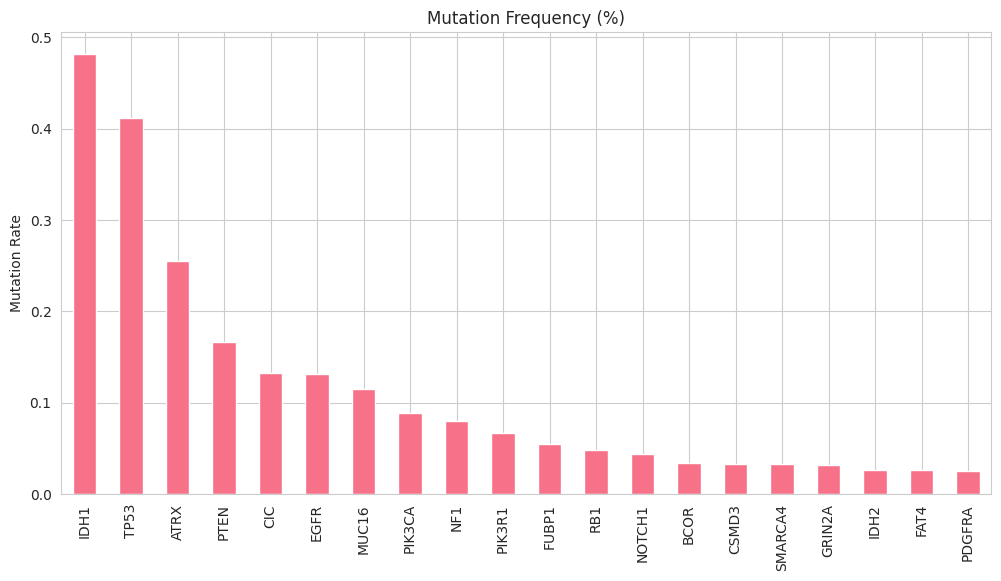

In [28]:
mutation_freq = df[mutation_cols].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))
mutation_freq.plot(kind='bar')
plt.title("Mutation Frequency (%)")
plt.ylabel("Mutation Rate")
plt.show()

<Figure size 1200x600 with 0 Axes>

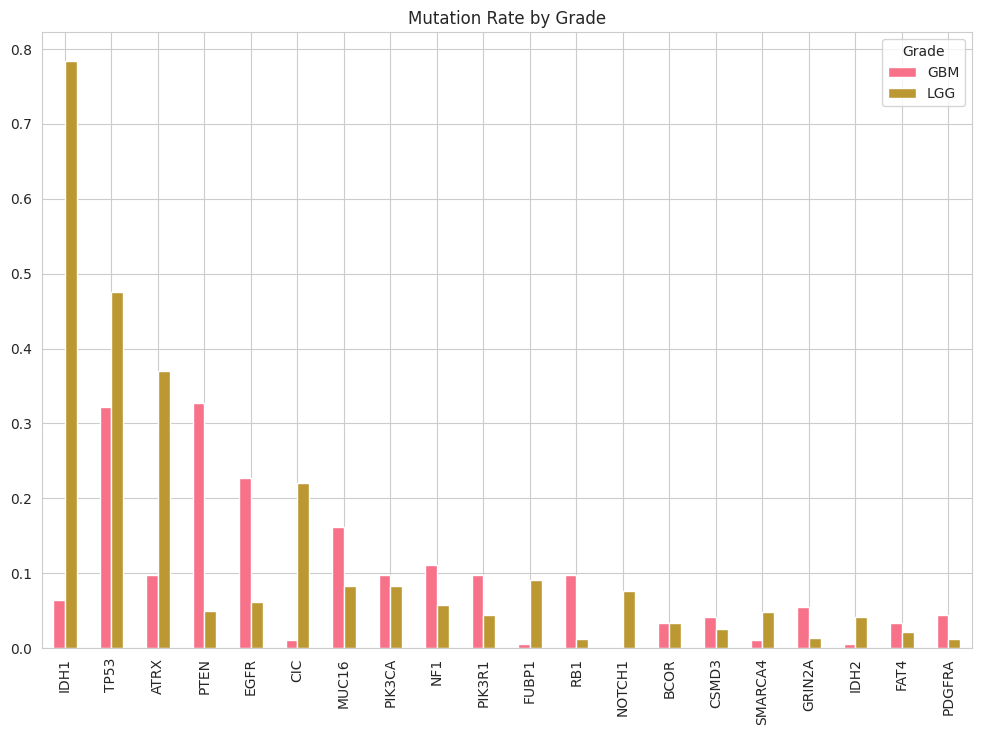

In [29]:
plt.figure(figsize=(12,6))
df.groupby('Grade')[mutation_cols].mean().T.plot(kind='bar')
plt.title("Mutation Rate by Grade")
plt.show()

In [30]:
for col in df.columns:
  numerical_features=["Age_at_diagnosis"]
  if col not in numerical_features:
    print(col,df[col].unique())
    print("-"*70)

Grade ['LGG' 'GBM']
----------------------------------------------------------------------
Gender [1 0]
----------------------------------------------------------------------
IDH1 [1 0]
----------------------------------------------------------------------
TP53 [0 1]
----------------------------------------------------------------------
ATRX [0 1]
----------------------------------------------------------------------
PTEN [0 1]
----------------------------------------------------------------------
EGFR [0 1]
----------------------------------------------------------------------
CIC [0 1]
----------------------------------------------------------------------
MUC16 [0 1]
----------------------------------------------------------------------
PIK3CA [1 0]
----------------------------------------------------------------------
NF1 [0 1]
----------------------------------------------------------------------
PIK3R1 [0 1]
----------------------------------------------------------------------
FU

In [31]:
y = df['Grade'].map({'LGG': 0, 'GBM': 1})
df['Grade'] = y



In [32]:
y

,Grade
0,0
1,0
2,0
3,0
4,0
...,...
857,1
858,1
859,1
860,1


Distribution de la variable cible 'Exited':

Nombre de patients ayant LGG (0): 498 (58.04%)
Nombre de pateints ayant GBM (1): 360 (41.96%)


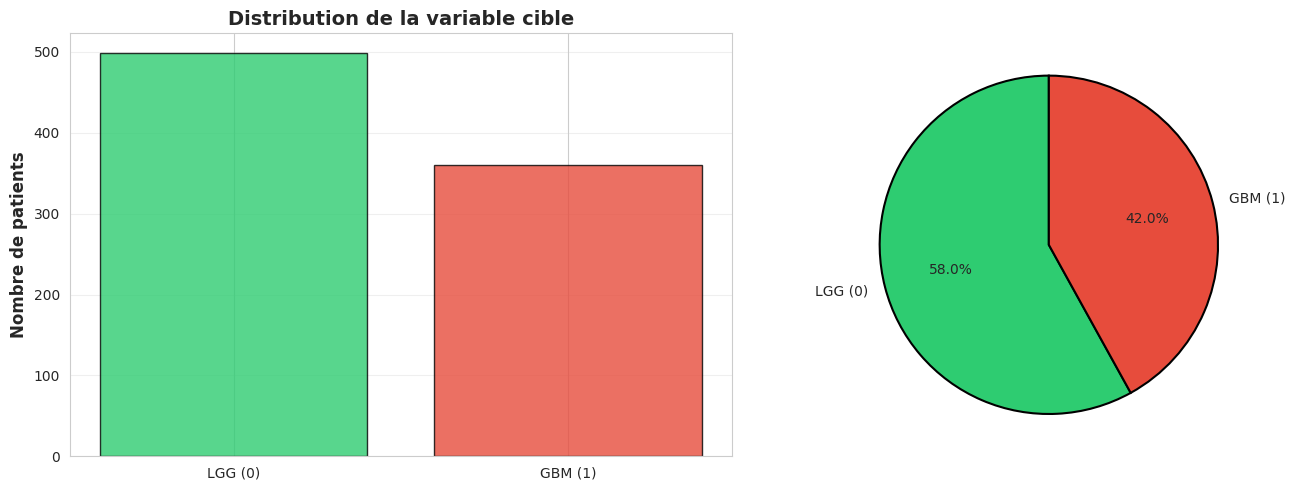

In [33]:
import matplotlib.pyplot as plt

# Distribution de la variable cible
target_counts=y.value_counts()
target_percentage=y.value_counts(normalize=True)*100


print("Distribution de la variable cible 'Exited':" , )
print("="*80)
print(f"\nNombre de patients ayant LGG (0): {target_counts[0]} ({target_percentage[0]:.2f}%)")
print(f"Nombre de pateints ayant GBM (1): {target_counts[1]} ({target_percentage[1]:.2f}%)")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
axes[0].bar(['LGG (0)', 'GBM (1)'], target_counts.values,
            color=['#2ecc71', '#e74c3c'], alpha=0.8, edgecolor='black')
axes[0].set_ylabel('Nombre de patients', fontsize=12, fontweight='bold')
axes[0].set_title('Distribution de la variable cible', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Pie chart
colors = ['#2ecc71', '#e74c3c']
axes[1].pie(target_counts.values, labels=['LGG (0)', 'GBM (1)'],
           autopct='%1.1f%%', colors=colors, startangle=90,
           wedgeprops={'edgecolor': 'black', 'linewidth': 1.5})


plt.tight_layout()
plt.show()

In [34]:
df

,Grade,Gender,Age_at_diagnosis,IDH1,TP53,ATRX,PTEN,EGFR,CIC,MUC16,...,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA,Race_asian,Race_black or african american,Race_white
0,0,1,51.295890,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,False,False,True
1,0,1,38.715068,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,False,False,True
2,0,1,35.169863,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,False,False,True
3,0,0,32.775342,1,1,1,0,0,0,1,...,0,0,0,0,0,1,0,False,False,True
4,0,1,31.512329,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
857,1,0,77.890411,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,False,False,True
858,1,1,85.178082,0,1,0,1,0,0,0,...,0,0,0,0,0,0,0,False,False,True
859,1,0,77.487671,0,1,0,1,0,0,0,...,0,0,0,0,0,0,0,False,False,True
860,1,1,63.331507,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,False,False,True


IndexError: index 12 is out of bounds for axis 0 with size 12

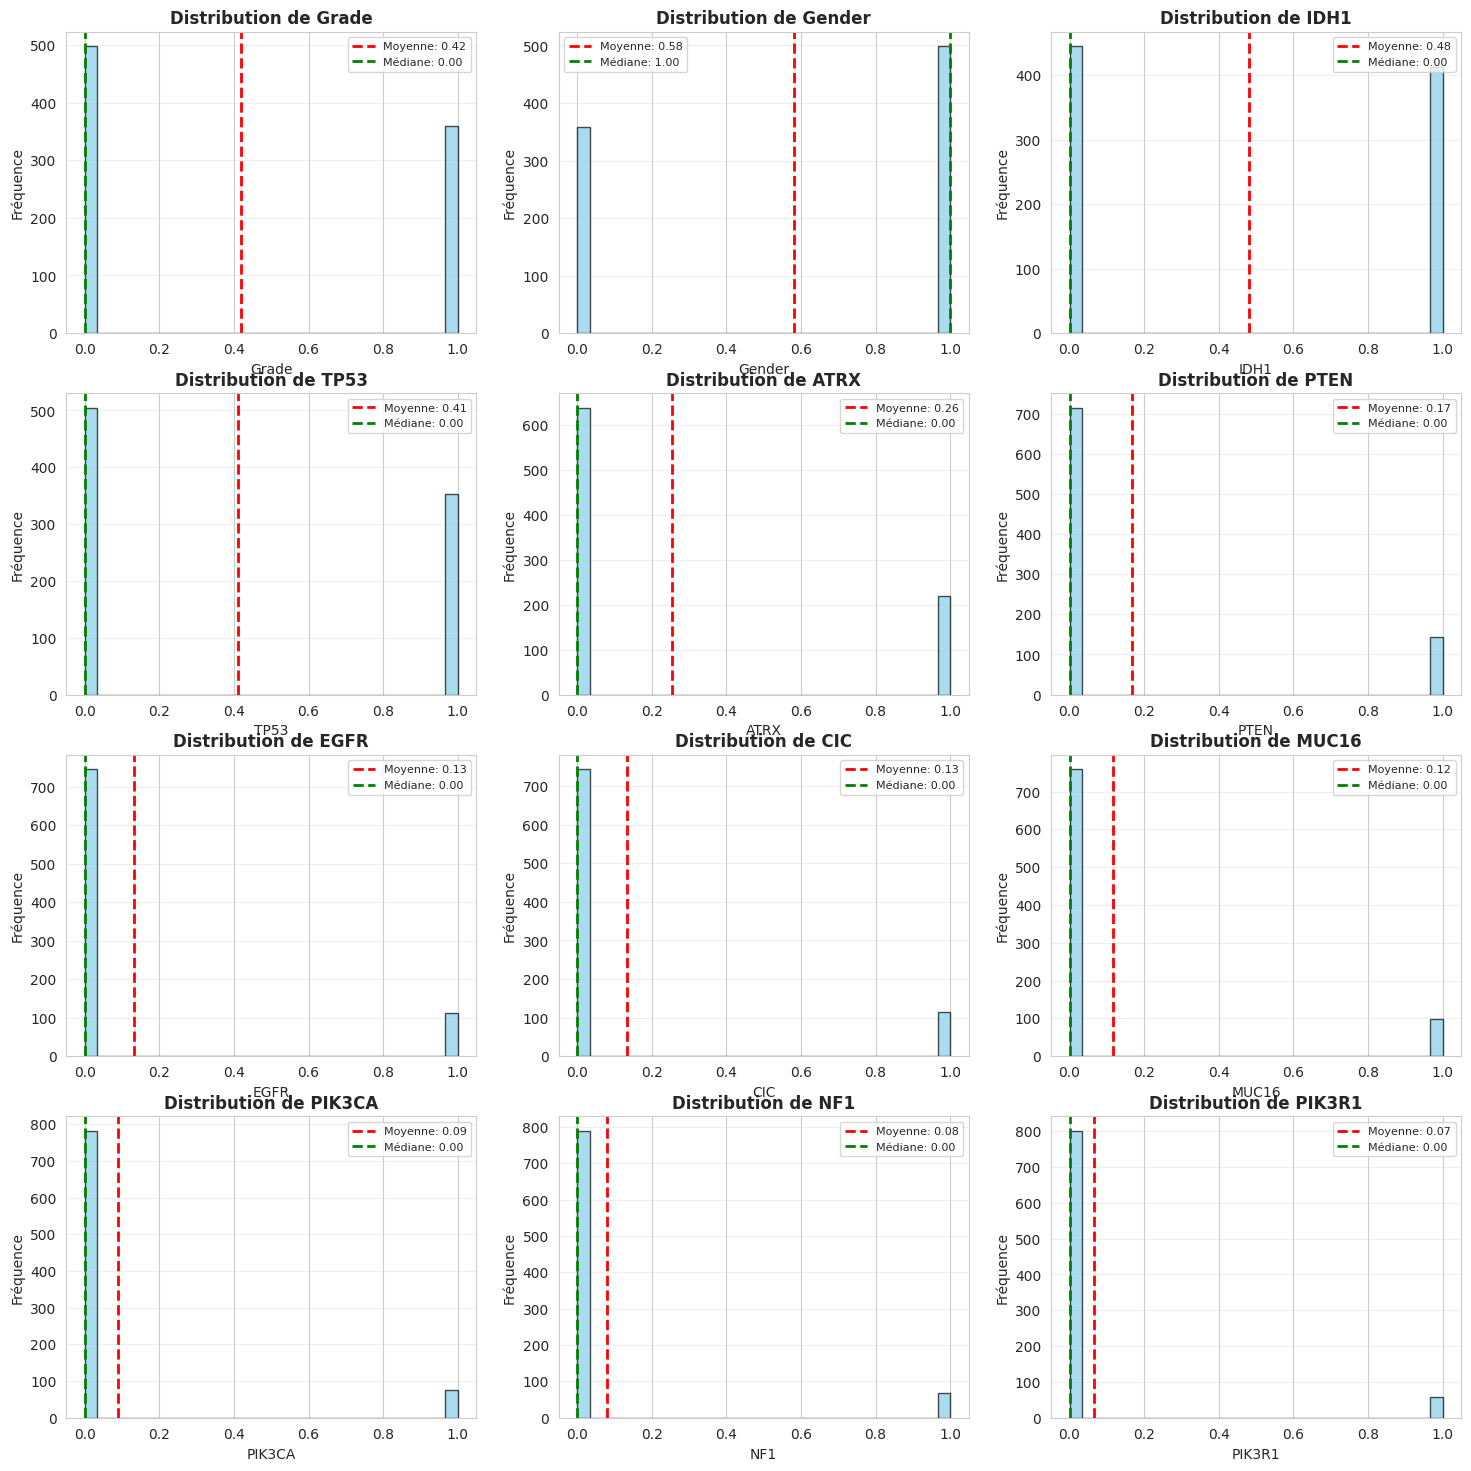

In [36]:
numerical_cols = df.select_dtypes(include=['int64', bool]).columns


fig, axes = plt.subplots(4, 3, figsize=(18, 18))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols):
    axes[idx].hist(df[col], bins=30, color='skyblue',
                   alpha=0.7, edgecolor='black')
    axes[idx].set_title(f'Distribution de {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col, fontsize=10)
    axes[idx].set_ylabel('Fréquence', fontsize=10)
    axes[idx].grid(axis='y', alpha=0.3)

    # Statistiques
    mean_val = df[col].mean()
    median_val = df[col].median()
    axes[idx].axvline(mean_val, color='red', linestyle='--',
                      linewidth=2, label=f'Moyenne: {mean_val:.2f}')
    axes[idx].axvline(median_val, color='green', linestyle='--',
                      linewidth=2, label=f'Médiane: {median_val:.2f}')
    axes[idx].legend(fontsize=8)

plt.tight_layout()
plt.show()

/tmp/ipython-input-1255799408.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[idx].boxplot([plot_data_0,
/tmp/ipython-input-1255799408.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[idx].boxplot([plot_data_0,
/tmp/ipython-input-1255799408.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[idx].boxplot([plot_data_0,
/tmp/ipython-input-1255799408.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[idx].boxplot([plot_data_0,
/tmp/ipython-input-1

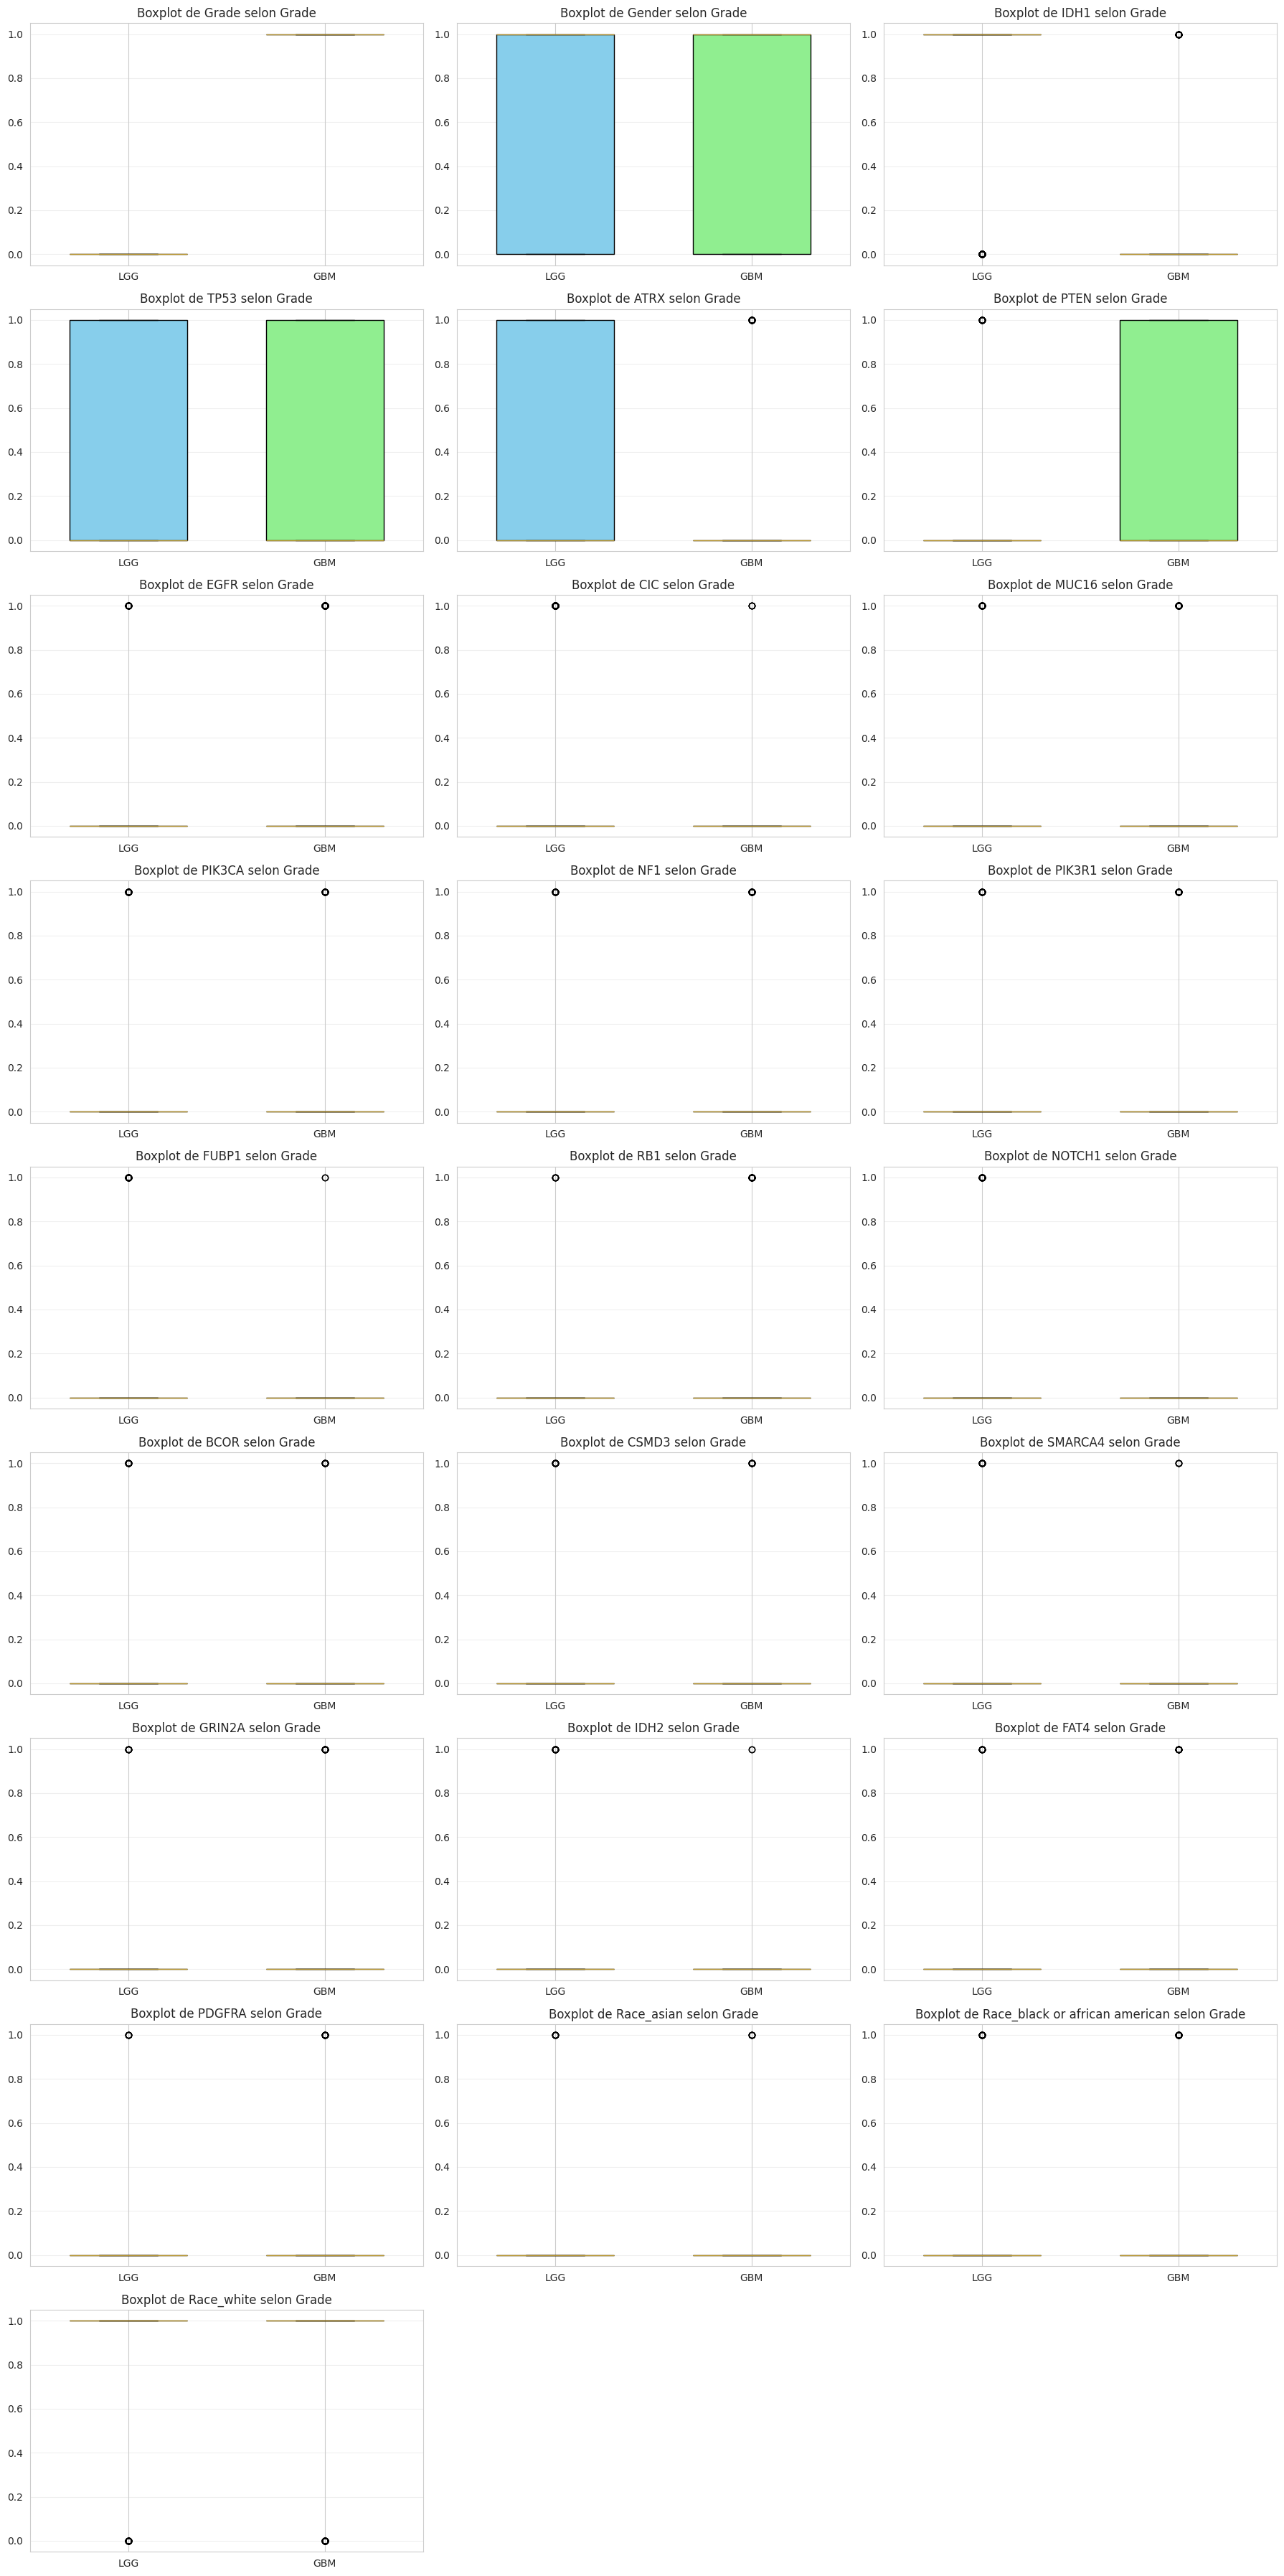

In [37]:
import math
# Get numerical and boolean columns
numerical_cols = df.select_dtypes(include=['int64', bool]).columns

n_cols = 3
n_rows = math.ceil(len(numerical_cols)/n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 4*n_rows))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols):
    # Convert boolean columns to int (0 or 1) for plotting if necessary
    plot_data_0 = df[y==0][col].dropna()
    plot_data_1 = df[y==1][col].dropna()

    if plot_data_0.dtype == bool:
        plot_data_0 = plot_data_0.astype(int)
    if plot_data_1.dtype == bool:
        plot_data_1 = plot_data_1.astype(int)

    bp = axes[idx].boxplot([plot_data_0,
                            plot_data_1],
                           labels=['LGG', 'GBM'],
                           patch_artist=True,
                           widths=0.6)

    # Couleurs
    colors = ['skyblue', 'lightgreen']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)

    axes[idx].set_title(f'Boxplot de {col} selon Grade', fontsize=12)
    axes[idx].grid(axis='y', alpha=0.3)

# Supprimer les axes vides si nécessaire
for j in range(idx+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [38]:

df

,Grade,Gender,Age_at_diagnosis,IDH1,TP53,ATRX,PTEN,EGFR,CIC,MUC16,...,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA,Race_asian,Race_black or african american,Race_white
0,0,1,51.295890,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,False,False,True
1,0,1,38.715068,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,False,False,True
2,0,1,35.169863,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,False,False,True
3,0,0,32.775342,1,1,1,0,0,0,1,...,0,0,0,0,0,1,0,False,False,True
4,0,1,31.512329,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
857,1,0,77.890411,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,False,False,True
858,1,1,85.178082,0,1,0,1,0,0,0,...,0,0,0,0,0,0,0,False,False,True
859,1,0,77.487671,0,1,0,1,0,0,0,...,0,0,0,0,0,0,0,False,False,True
860,1,1,63.331507,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,False,False,True


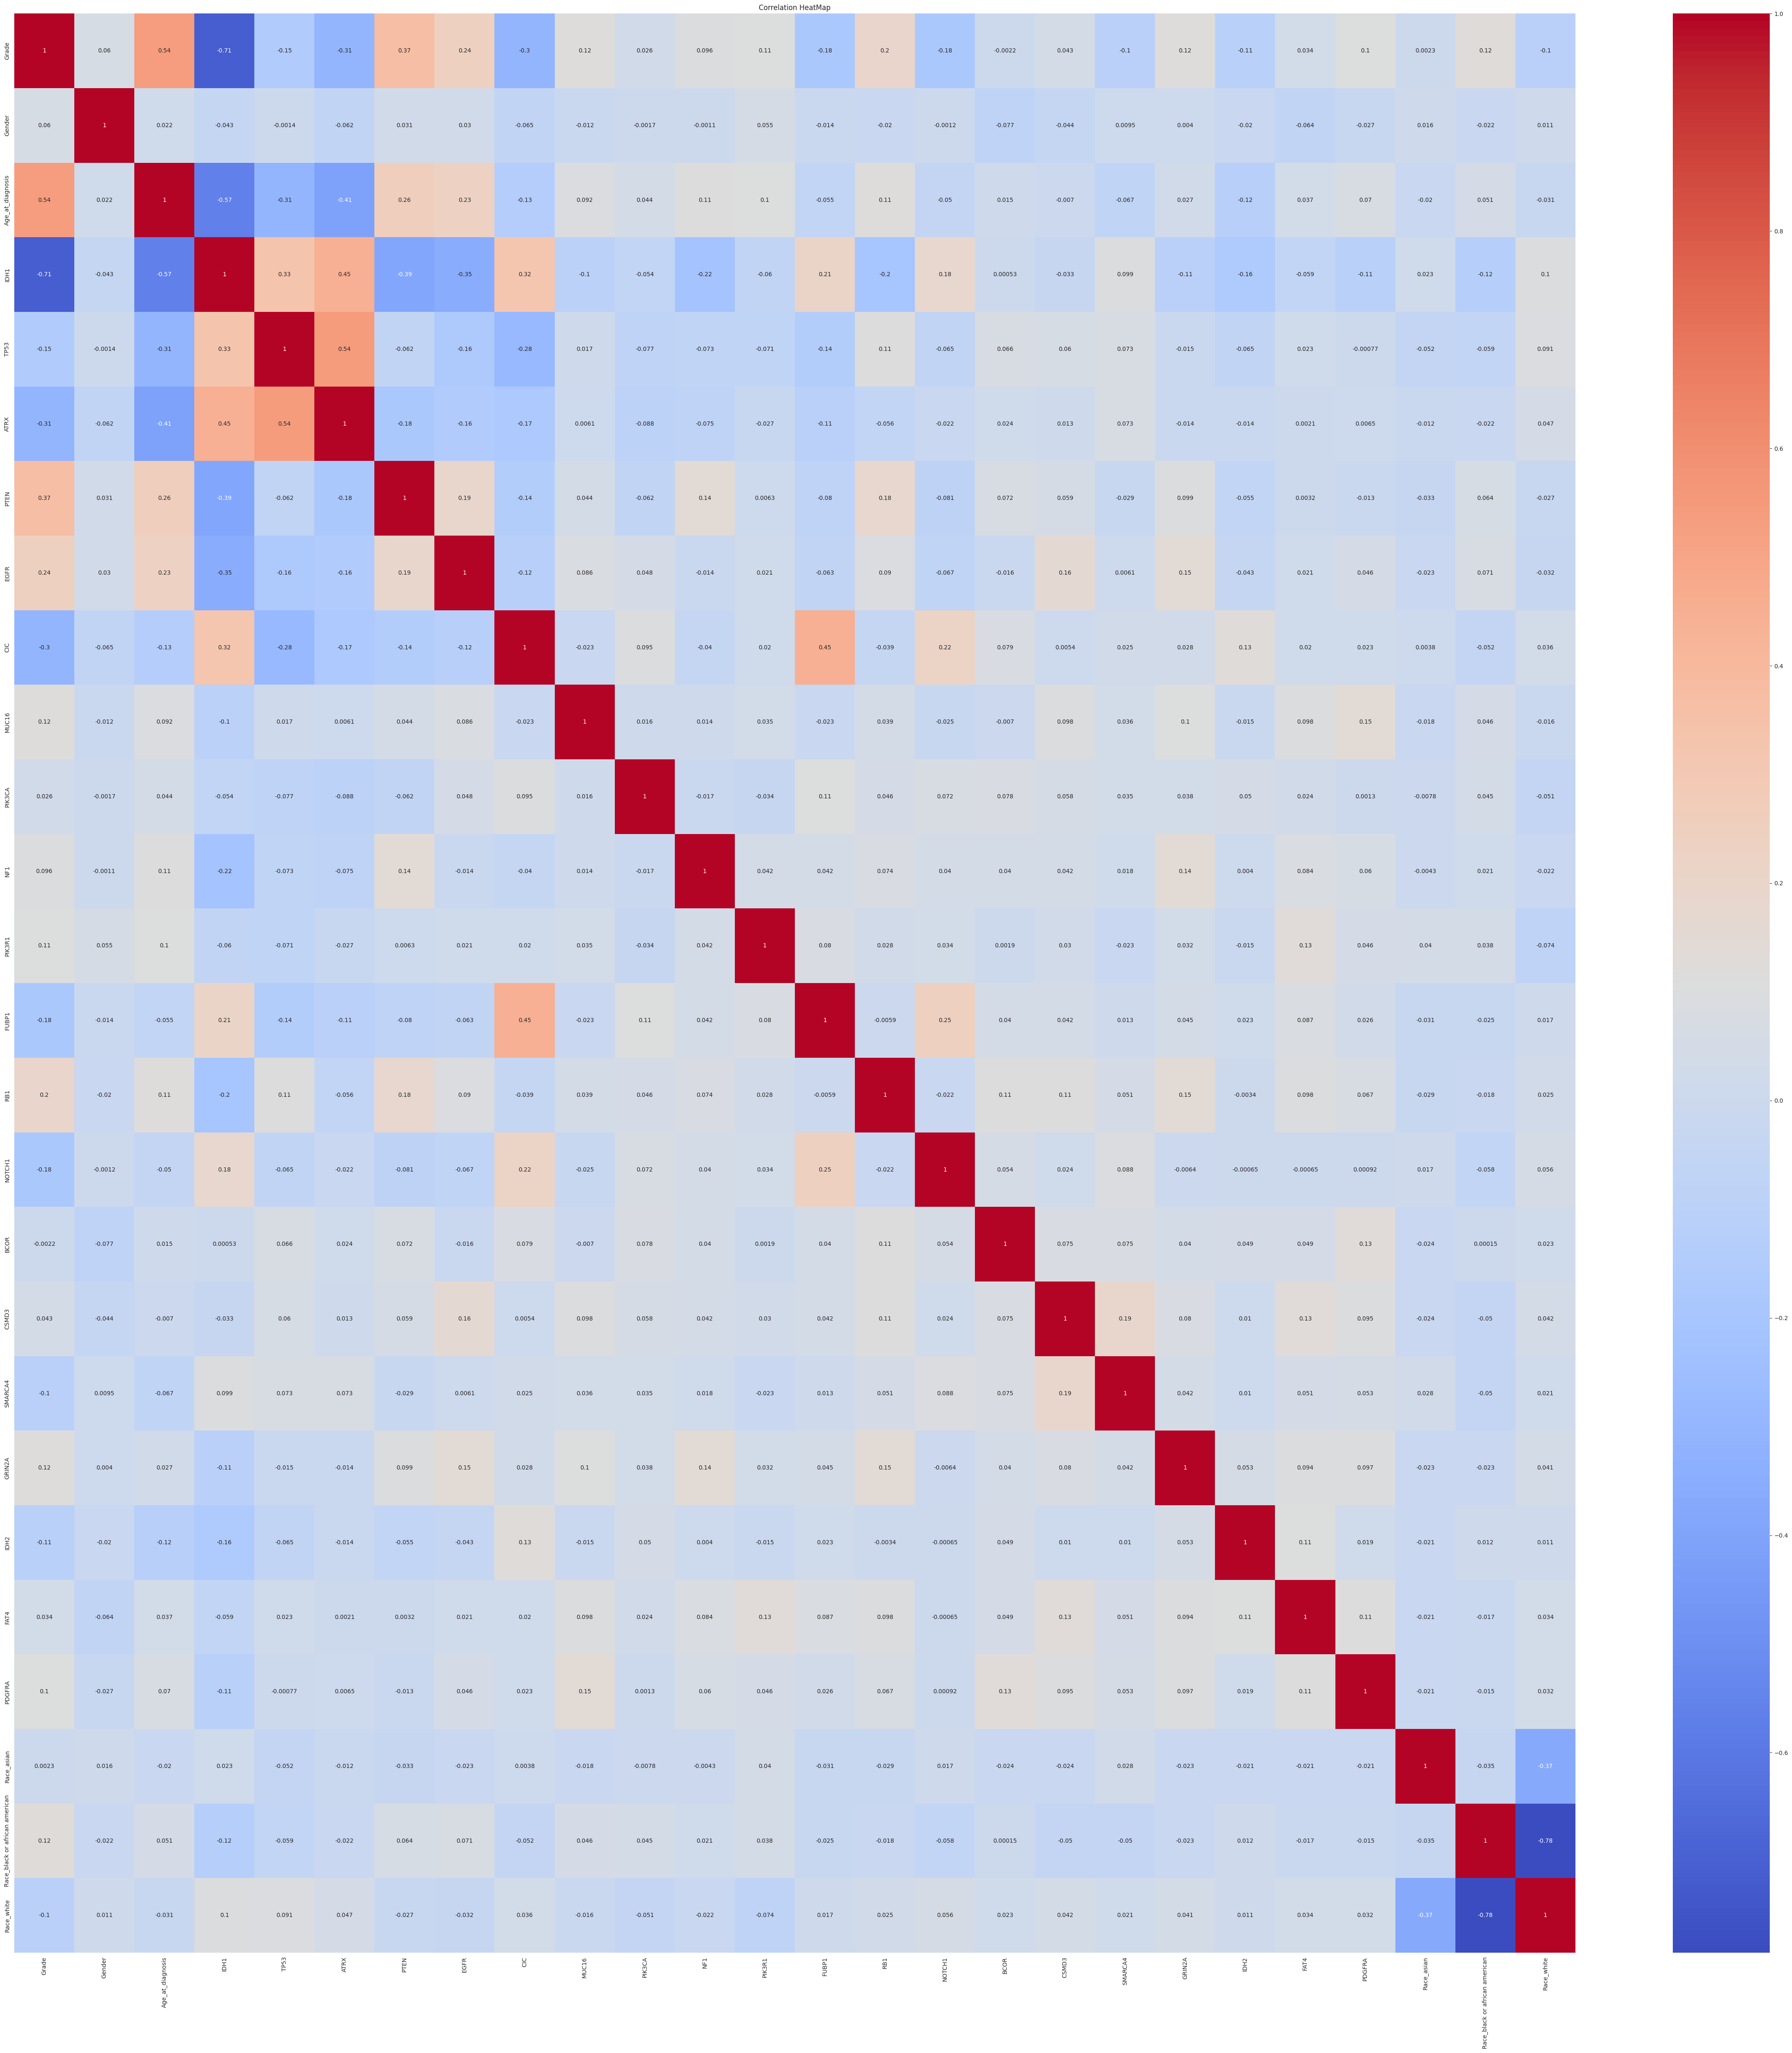

In [39]:
import matplotlib.pyplot as plt
!pip install --upgrade seaborn # Ensure seaborn is installed and up-to-date
import seaborn as sns

plt.figure(figsize=(60,60))
sns.heatmap(df.corr(),annot =True , cmap="coolwarm")
plt.title("Correlation HeatMap")
plt.show()

In [40]:
df.describe()

,Grade,Gender,Age_at_diagnosis,IDH1,TP53,ATRX,PTEN,EGFR,CIC,MUC16,...,FUBP1,RB1,NOTCH1,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA
count,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,...,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000
mean,0.419580,0.581585,50.865600,0.481352,0.411422,0.255245,0.166667,0.131702,0.132867,0.115385,...,0.054779,0.047786,0.044289,0.033800,0.032634,0.032634,0.031469,0.026807,0.026807,0.025641
std,0.493778,0.493587,15.665552,0.499944,0.492378,0.436253,0.372895,0.338363,0.339629,0.319672,...,0.227680,0.213437,0.205857,0.180818,0.177780,0.177780,0.174682,0.161612,0.161612,0.158154
min,0.000000,0.000000,14.421918,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,38.025342,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,1.000000,51.471233,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,1.000000,62.606849,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,89.287671,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [41]:
X = df.drop('Grade', axis=1)
y = df['Grade']


In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [43]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Exemple avec ton dataset
# Supposons que df est ton DataFrame et 'Age_at_diagnosis' est la colonne à normaliser
scaler = MinMaxScaler()  # crée l'objet scaler

# On reshape la colonne car MinMaxScaler attend un 2D array
X_train['Age_at_diagnosis'] = scaler.fit_transform(X_train[['Age_at_diagnosis']])
X_test['Age_at_diagnosis'] = scaler.transform(X_test[['Age_at_diagnosis']])



In [44]:
X_train['Age_at_diagnosis']

,Age_at_diagnosis
449,0.188502
26,0.501866
169,0.695162
201,0.302715
628,0.679024
...,...
379,0.540291
229,0.337517
416,0.256862
334,0.236734


#Modelisation

In [45]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    """
    Fonction pour évaluer les performances d'un modèle
    """
    # Prédictions
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    # Probabilités pour ROC-AUC
    if hasattr(model, 'predict_proba'):
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_pred_proba)
    else:
        roc_auc = None

    # Métriques
    results = {
        'Modèle': name,
        'Accuracy Train': accuracy_score(y_train, y_pred_train),
        'Accuracy Test': accuracy_score(y_test, y_pred_test),
        'Precision': precision_score(y_test, y_pred_test),
        'Recall': recall_score(y_test, y_pred_test),
        'F1-Score': f1_score(y_test, y_pred_test),
        'ROC-AUC': roc_auc
    }

    # Affichage
    print(f"\n{'='*80}")
    print(f"MODÈLE: {name}")
    print(f"{'='*80}")

    for metric, value in results.items():
        if metric != 'Modèle':
            if value is not None:
                print(f"{metric:20s}: {value:.4f}")
            else:
                print(f"{metric:20s}: N/A")

    # Matrice de confusion
    cm = confusion_matrix(y_test, y_pred_test)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
                xticklabels=['LGG', 'GBM'],
                yticklabels=['LGG', 'GBM'])
    plt.title(f'Matrice de Confusion - {name}', fontsize=14, fontweight='bold')
    plt.ylabel('Vraie Classe', fontsize=12)
    plt.xlabel('Classe Prédite', fontsize=12)
    plt.tight_layout()
    plt.show()

    # Rapport de classification
    print(f"\nRapport de classification:")
    print(classification_report(y_test, y_pred_test,
                                target_names=['LGG', 'GBM']))

    return results

Entraînement du modèle Logistic Regression...

MODÈLE: Logistic Regression
Accuracy Train      : 0.8790
Accuracy Test       : 0.8663
Precision           : 0.8025
Recall              : 0.9028
F1-Score            : 0.8497
ROC-AUC             : 0.8875


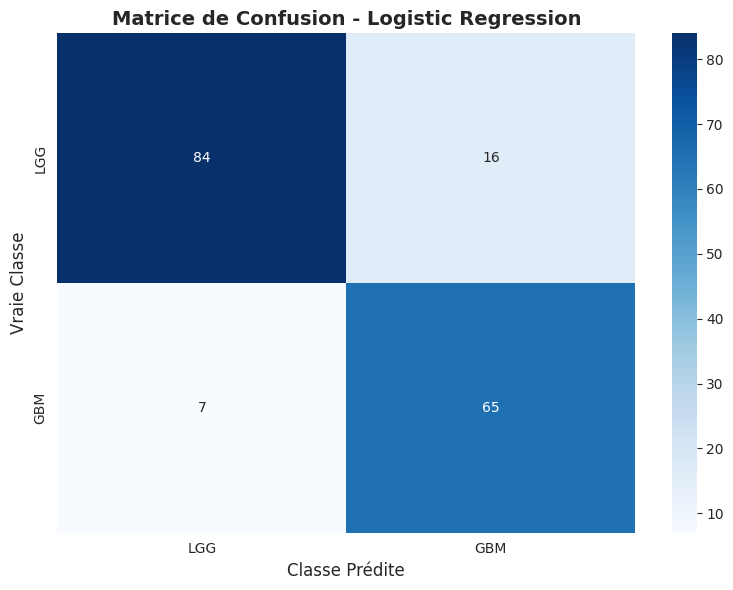


Rapport de classification:
              precision    recall  f1-score   support

         LGG       0.92      0.84      0.88       100
         GBM       0.80      0.90      0.85        72

    accuracy                           0.87       172
   macro avg       0.86      0.87      0.86       172
weighted avg       0.87      0.87      0.87       172



In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

print("Entraînement du modèle Logistic Regression...")
# Entraînement du modèle Logistic Regression
lr = LogisticRegression(random_state=42)
lr.fit(X_train, y_train)

# Évaluation
results_lr = evaluate_model('Logistic Regression', lr,
                            X_train, X_test,
                            y_train, y_test)

In [47]:
dt = LogisticRegression(random_state=42)
dt.fit(X_train, y_train)

print(f"Accuracy Train: {dt.score(X_train, y_train):.4f}")
print(f"Accuracy Test:  {dt.score(X_test, y_test):.4f}")

Accuracy Train: 0.8790
Accuracy Test:  0.8663


Entraînement du modèle Decision Tree...

MODÈLE: Decision Tree
Accuracy Train      : 0.8950
Accuracy Test       : 0.8547
Precision           : 0.7901
Recall              : 0.8889
F1-Score            : 0.8366
ROC-AUC             : 0.8865


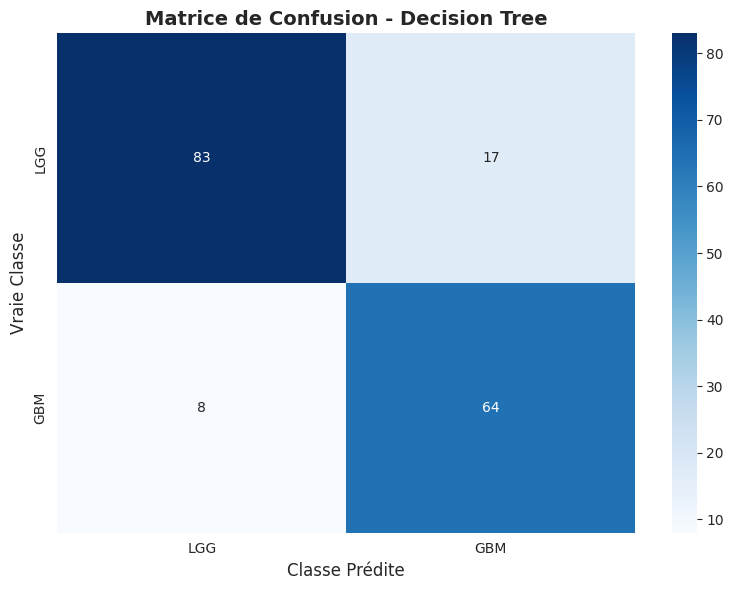


Rapport de classification:
              precision    recall  f1-score   support

         LGG       0.91      0.83      0.87       100
         GBM       0.79      0.89      0.84        72

    accuracy                           0.85       172
   macro avg       0.85      0.86      0.85       172
weighted avg       0.86      0.85      0.86       172



In [48]:
from sklearn.tree import DecisionTreeClassifier

print("Entraînement du modèle Decision Tree...")
# Entraînement du modèle Decision Tree
dt = DecisionTreeClassifier(max_depth=5 ,random_state=42)
dt.fit(X_train, y_train)

# Évaluation
results_dt = evaluate_model('Decision Tree', dt,
                           X_train, X_test,
                           y_train, y_test)

Entraînement du modèle K-Nearest Neighbors...

MODÈLE: K-Nearest Neighbors
Accuracy Train      : 0.8863
Accuracy Test       : 0.8256
Precision           : 0.7625
Recall              : 0.8472
F1-Score            : 0.8026
ROC-AUC             : 0.8703


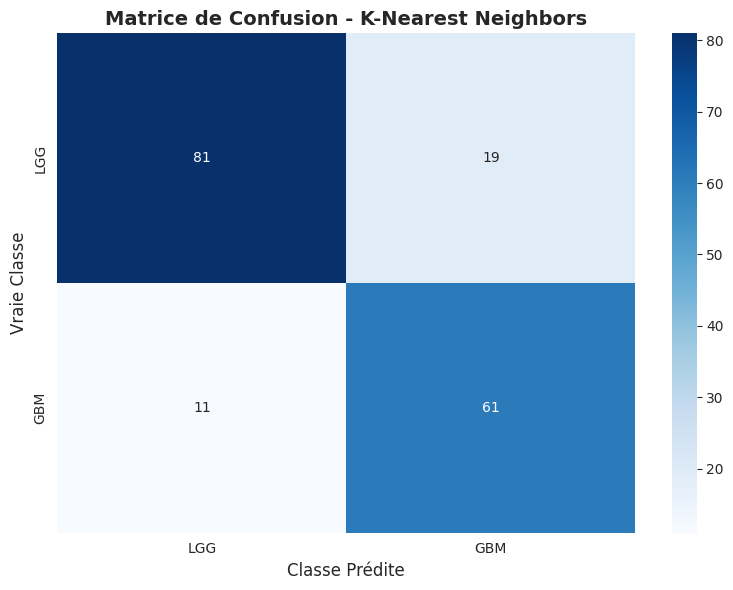


Rapport de classification:
              precision    recall  f1-score   support

         LGG       0.88      0.81      0.84       100
         GBM       0.76      0.85      0.80        72

    accuracy                           0.83       172
   macro avg       0.82      0.83      0.82       172
weighted avg       0.83      0.83      0.83       172



In [49]:
from sklearn.neighbors import KNeighborsClassifier

print("Entraînement du modèle K-Nearest Neighbors...")
# Entraînement du modèle KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Évaluation
results_knn = evaluate_model('K-Nearest Neighbors', knn,
                             X_train, X_test,
                             y_train, y_test)

Entraînement du modèle Random Forest...

MODÈLE: Random Forest
Accuracy Train      : 0.8834
Accuracy Test       : 0.8547
Precision           : 0.7901
Recall              : 0.8889
F1-Score            : 0.8366
ROC-AUC             : 0.8834


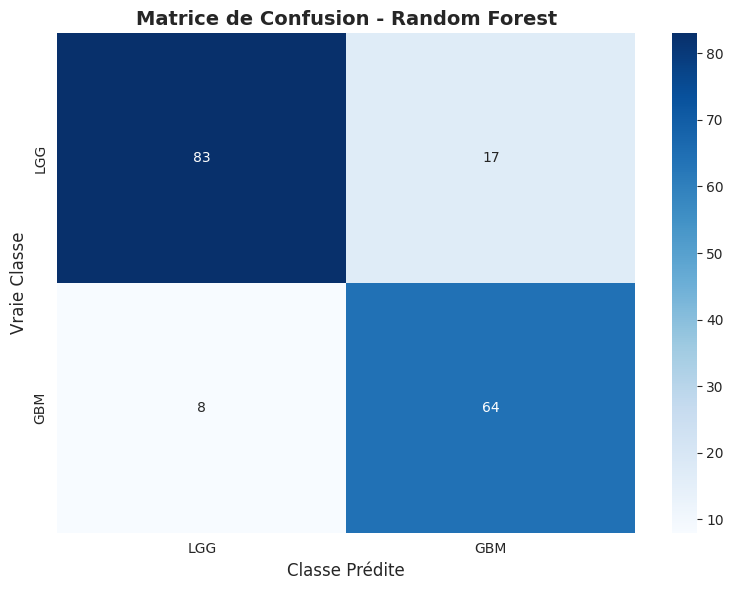


Rapport de classification:
              precision    recall  f1-score   support

         LGG       0.91      0.83      0.87       100
         GBM       0.79      0.89      0.84        72

    accuracy                           0.85       172
   macro avg       0.85      0.86      0.85       172
weighted avg       0.86      0.85      0.86       172



In [50]:
from sklearn.ensemble import RandomForestClassifier

print("Entraînement du modèle Random Forest...")
# Entraînement du modèle Random Forest
rf = RandomForestClassifier(max_depth=5 ,random_state=42)
rf.fit(X_train, y_train)

# Évaluation
results_rf = evaluate_model('Random Forest', rf,
                           X_train, X_test,
                           y_train, y_test)

Entraînement du modèle XGBoost...

MODÈLE: XGBoost
Accuracy Train      : 0.9869
Accuracy Test       : 0.8198
Precision           : 0.7887
Recall              : 0.7778
F1-Score            : 0.7832
ROC-AUC             : 0.8726


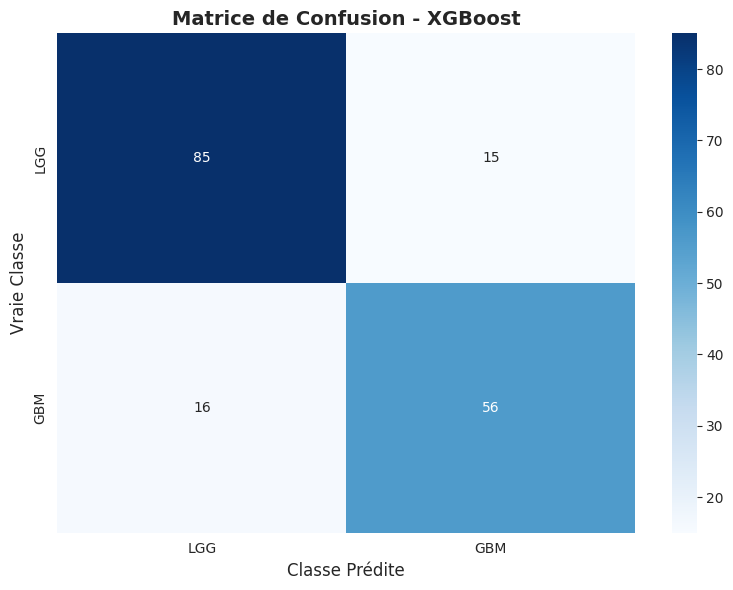


Rapport de classification:
              precision    recall  f1-score   support

         LGG       0.84      0.85      0.85       100
         GBM       0.79      0.78      0.78        72

    accuracy                           0.82       172
   macro avg       0.82      0.81      0.81       172
weighted avg       0.82      0.82      0.82       172



In [51]:
# Entraînement du modèle XGBoost
print("Entraînement du modèle XGBoost...")
xgb = XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1, eval_metric='logloss')
xgb.fit(X_train, y_train)

# Évaluation
results_xgb = evaluate_model('XGBoost', xgb,
                            X_train, X_test,
                            y_train, y_test)


COMPARAISON DES MODÈLES BASELINE
                     Accuracy Train  Accuracy Test  Precision    Recall  F1-Score   ROC-AUC
Modèle                                                                                     
K-Nearest Neighbors        0.886297       0.825581   0.762500  0.847222  0.802632  0.870278
Logistic Regression        0.879009       0.866279   0.802469  0.902778  0.849673  0.887500
Decision Tree              0.895044       0.854651   0.790123  0.888889  0.836601  0.886528
Random Forest              0.883382       0.854651   0.790123  0.888889  0.836601  0.883403
XGBoost                    0.986880       0.819767   0.788732  0.777778  0.783217  0.872639


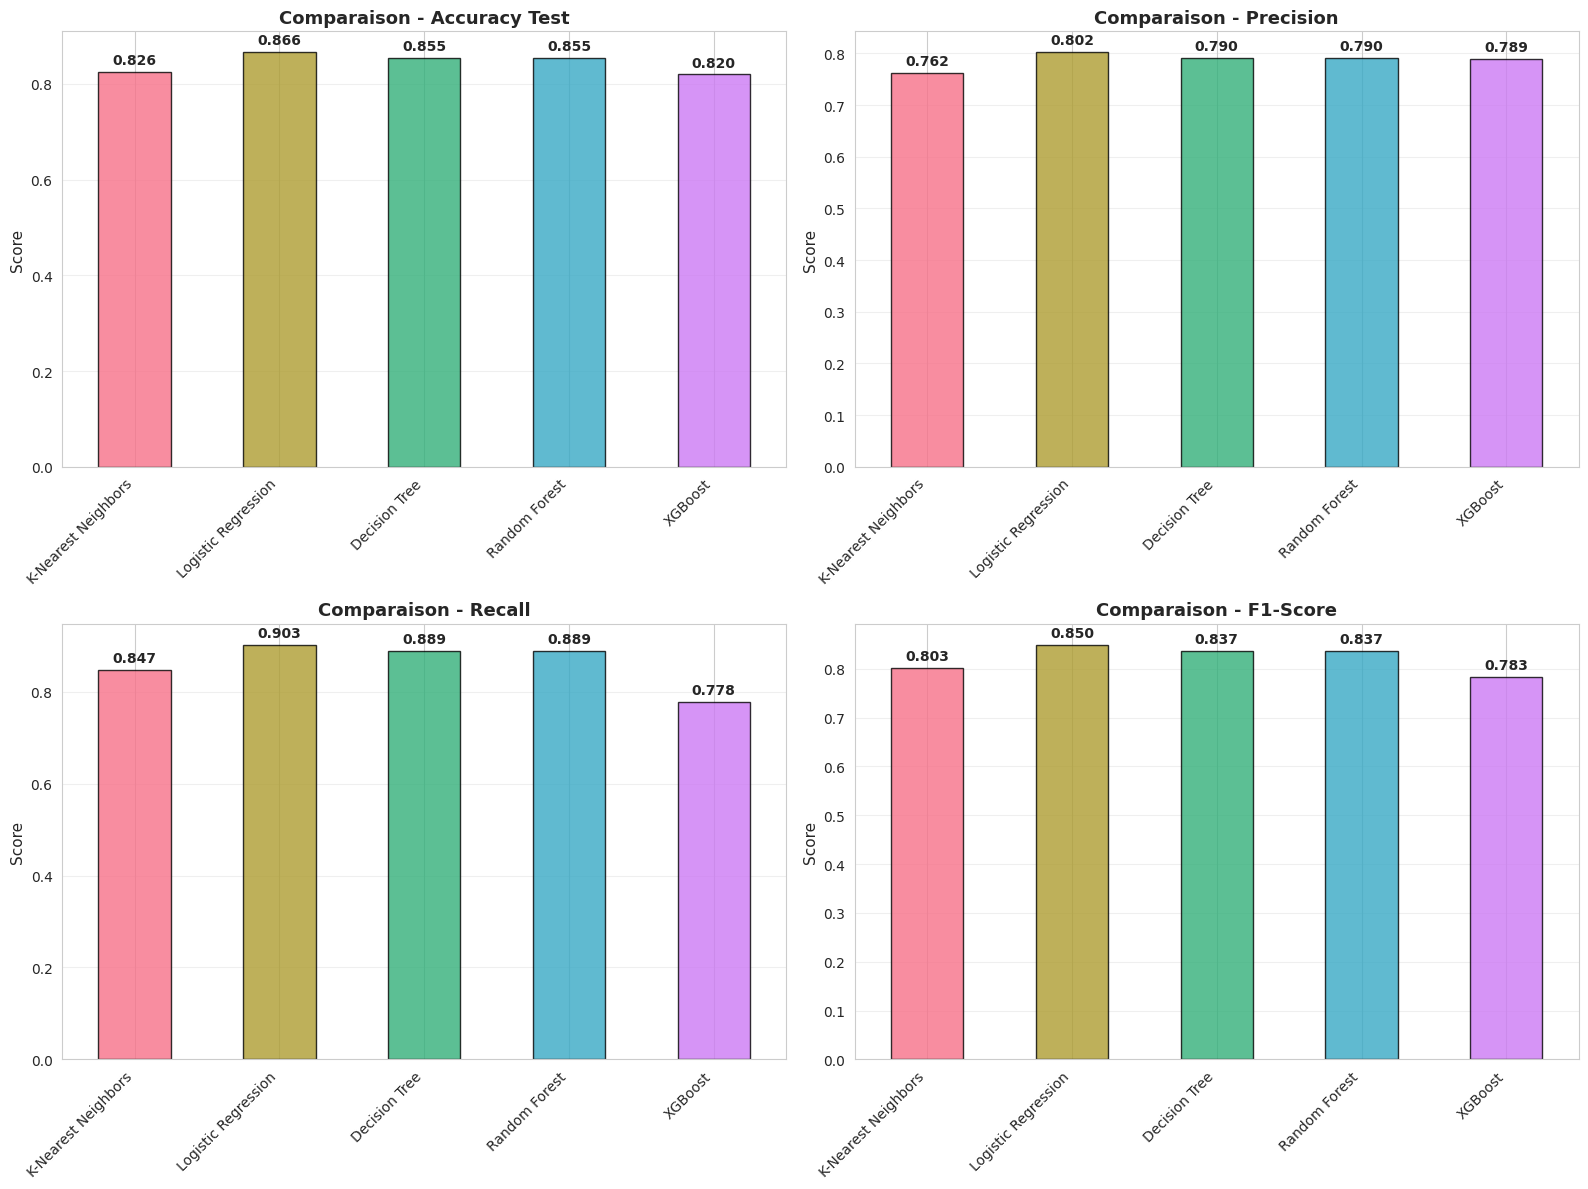

In [52]:
# Comparaison des résultats
comparison_df = pd.DataFrame([results_knn, results_lr, results_dt, results_rf, results_xgb])
comparison_df = comparison_df.set_index('Modèle')

print("\n" + "="*100)
print("COMPARAISON DES MODÈLES BASELINE")
print("="*100)
print(comparison_df.to_string())

# Visualisation comparative
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics = ['Accuracy Test', 'Precision', 'Recall', 'F1-Score']
colors_palette = sns.color_palette('husl', len(comparison_df))

for idx, metric in enumerate(metrics):
    row = idx // 2
    col = idx % 2

    comparison_df[metric].plot(kind='bar', ax=axes[row, col],
                               color=colors_palette, alpha=0.8, edgecolor='black')
    axes[row, col].set_title(f'Comparaison - {metric}', fontsize=13, fontweight='bold')
    axes[row, col].set_ylabel('Score', fontsize=11)
    axes[row, col].set_xlabel('')
    axes[row, col].grid(axis='y', alpha=0.3)
    axes[row, col].set_xticklabels(axes[row, col].get_xticklabels(), rotation=45, ha='right')

    # Ajouter les valeurs sur les barres
    for i, v in enumerate(comparison_df[metric]):
        axes[row, col].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [53]:
# Sélection des 3 meilleurs modèles basés sur le F1-Score
best_models_idx = comparison_df['F1-Score'].nlargest(3).index
print("Top 3 modèles sélectionnés pour le fine-tuning:")
print("="*80)
for i, model_name in enumerate(best_models_idx, 1):
    print(f"{i}. {model_name} - F1-Score: {comparison_df.loc[model_name, 'F1-Score']:.4f}")

Top 3 modèles sélectionnés pour le fine-tuning:
1. Logistic Regression - F1-Score: 0.8497
2. Decision Tree - F1-Score: 0.8366
3. Random Forest - F1-Score: 0.8366



FINE-TUNING: Logistic Regression
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Meilleurs paramètres trouvés:
  C: 1
  penalty: l1
  solver: liblinear

Meilleur score (F1) en validation croisée: 0.8612

MODÈLE: Logistic Regression (Tuned)
Accuracy Train      : 0.8776
Accuracy Test       : 0.8663
Precision           : 0.8025
Recall              : 0.9028
F1-Score            : 0.8497
ROC-AUC             : 0.8867


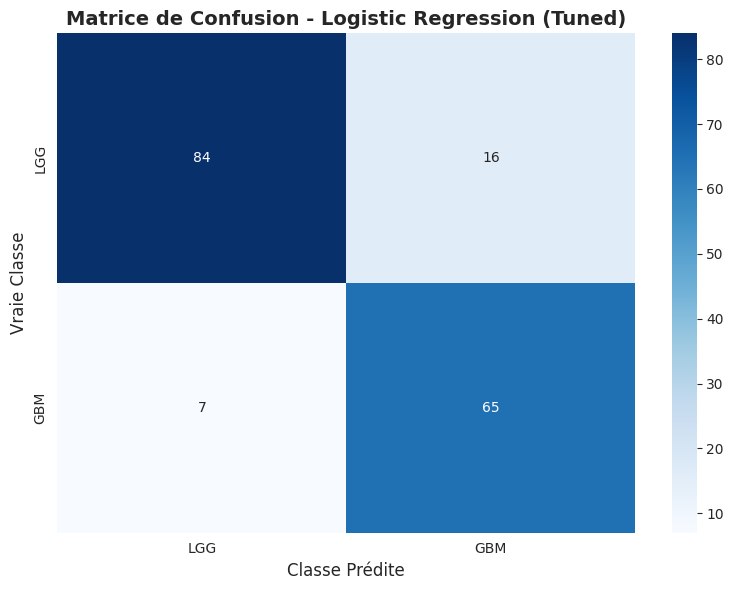


Rapport de classification:
              precision    recall  f1-score   support

         LGG       0.92      0.84      0.88       100
         GBM       0.80      0.90      0.85        72

    accuracy                           0.87       172
   macro avg       0.86      0.87      0.86       172
weighted avg       0.87      0.87      0.87       172


FINE-TUNING: Random Forest
Fitting 5 folds for each of 54 candidates, totalling 270 fits

Meilleurs paramètres trouvés:
  max_depth: 5
  min_samples_leaf: 1
  min_samples_split: 10
  n_estimators: 100

Meilleur score (F1) en validation croisée: 0.8640

MODÈLE: Random Forest (Tuned)
Accuracy Train      : 0.8834
Accuracy Test       : 0.8547
Precision           : 0.7901
Recall              : 0.8889
F1-Score            : 0.8366
ROC-AUC             : 0.8762


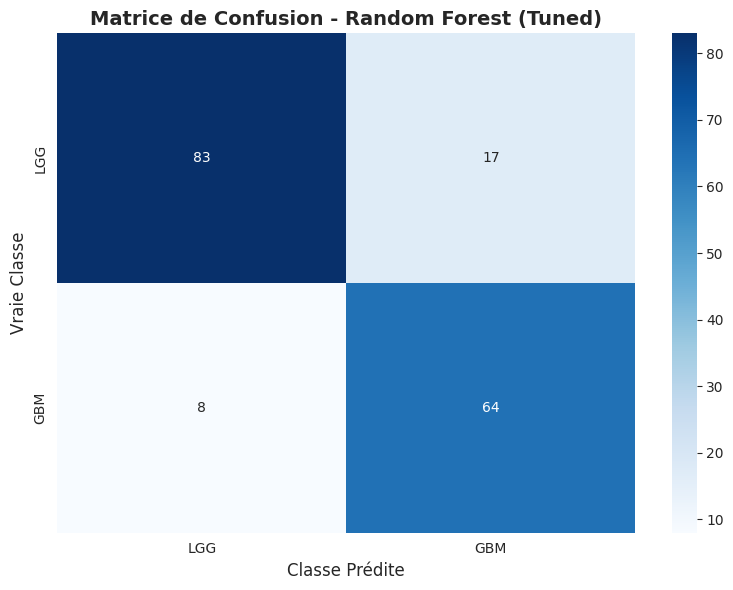


Rapport de classification:
              precision    recall  f1-score   support

         LGG       0.91      0.83      0.87       100
         GBM       0.79      0.89      0.84        72

    accuracy                           0.85       172
   macro avg       0.85      0.86      0.85       172
weighted avg       0.86      0.85      0.86       172


FINE-TUNING: XGBoost
Fitting 5 folds for each of 243 candidates, totalling 1215 fits

Meilleurs paramètres trouvés:
  colsample_bytree: 0.6
  learning_rate: 0.01
  max_depth: 5
  n_estimators: 300
  subsample: 1.0

Meilleur score (F1) en validation croisée: 0.8584

MODÈLE: XGBoost (Tuned)
Accuracy Train      : 0.8892
Accuracy Test       : 0.8721
Precision           : 0.8125
Recall              : 0.9028
F1-Score            : 0.8553
ROC-AUC             : 0.8845


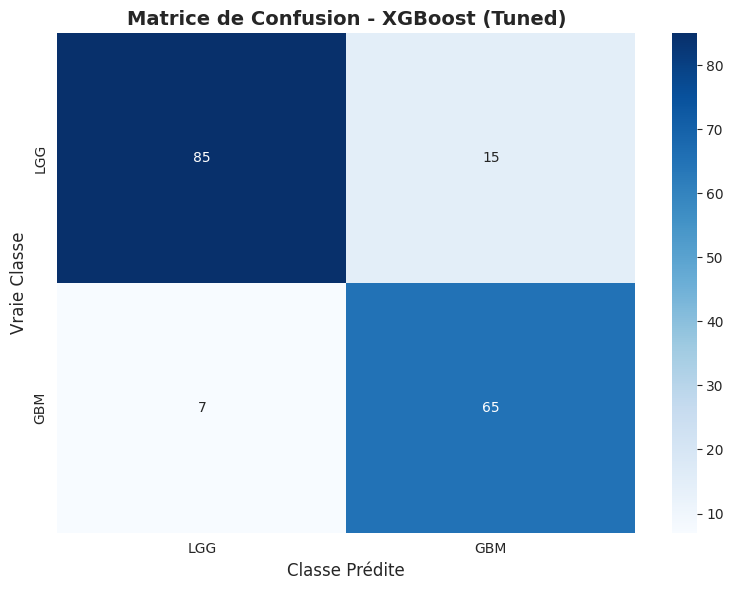


Rapport de classification:
              precision    recall  f1-score   support

         LGG       0.92      0.85      0.89       100
         GBM       0.81      0.90      0.86        72

    accuracy                           0.87       172
   macro avg       0.87      0.88      0.87       172
weighted avg       0.88      0.87      0.87       172



In [56]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Dictionnaire des modèles et paramètres à tuner
models_to_tune = {
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=1000, random_state=42),
        'params': {
            'C': [0.001, 0.01, 0.1, 1, 10, 100],
            'penalty': ['l1', 'l2'],
            'solver': ['liblinear']
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42, n_jobs=-1),
        'params': {
            'n_estimators': [100, 200, 300],
            'max_depth': [3, 5],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4]
        }
    },
    'XGBoost': {
        'model': XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss'),
        'params': {
            'n_estimators': [100, 200, 300],
            'max_depth': [3, 5, 7],
            'learning_rate': [0.01, 0.1, 0.2],
            'subsample': [0.6, 0.8, 1.0],
            'colsample_bytree': [0.6, 0.8, 1.0]
        }
    }
}

# Stockage des modèles tunés
tuned_models = {}
tuned_results = []

for model_name, config in models_to_tune.items():
    print(f"\n{'='*80}")
    print(f"FINE-TUNING: {model_name}")
    print(f"{'='*80}")

    # GridSearchCV
    grid_search = GridSearchCV(
        estimator=config['model'],
        param_grid=config['params'],
        cv=5,
        scoring='f1',
        n_jobs=-1,
        verbose=1
    )

    grid_search.fit(X_train, y_train)

    print(f"\nMeilleurs paramètres trouvés:")
    for param, value in grid_search.best_params_.items():
        print(f"  {param}: {value}")

    print(f"\nMeilleur score (F1) en validation croisée: {grid_search.best_score_:.4f}")

    # Stocker le meilleur modèle
    tuned_models[model_name] = grid_search.best_estimator_

    # Évaluation sur le test set
    results = evaluate_model(f'{model_name} (Tuned)',
                            grid_search.best_estimator_,
                            X_train, X_test,
                            y_train, y_test)
    tuned_results.append(results)